In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# **Comparing Model Results**

In [2]:
# each model notebook writes its test MAE to its own txt file when it runs
files = {
    "Linear Regression": "../data/2_model_linear_regression_results.txt",
    "Ridge": "../data/3_model_ridge_regression_results.txt",
    "Lasso": "../data/4_model_lasso_regression_results.txt",
}

results = {}
for name, path in files.items():
    with open(path) as f:
        results[name] = float(f.read())

results

{'Linear Regression': 25206.38766024195,
 'Ridge': 25109.7715198679,
 'Lasso': 25184.14703366058}

In [3]:
result_df = pd.Series(results, name="test_mae").sort_values()
result_df

Ridge                25109.771520
Lasso                25184.147034
Linear Regression    25206.387660
Name: test_mae, dtype: float64

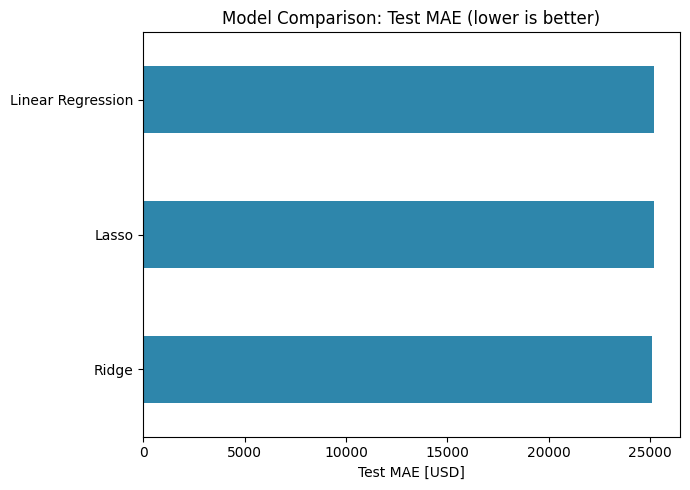

In [4]:
plt.figure(figsize=(7,5))
result_df.plot(kind="barh", color="#2E86AB")
plt.xlabel("Test MAE [USD]")
plt.title("Model Comparison: Test MAE (lower is better)")
plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=150)
plt.show()


**Result:** all three models land close together, which makes sense -- they're all
linear models pulling from the same features. Ridge comes out slightly ahead of plain
Linear Regression and Lasso here, likely because it handles the 57 one-hot-encoded
neighborhood columns a bit more gracefully than an unregularized model, without zeroing
out neighborhoods entirely the way Lasso can.

Going with **Ridge** as the final model for this project.